# mSPRT and sequential testing for AI product experiments

**Product Experimentation: stop early without p-hacking using mSPRT and sequential testing in Python**

**Keywords:** product experimentation, causal inference, sequential testing, mSPRT, e-values, always-valid inference, LLM product experiments, optional stopping, A/B testing, Bernoulli outcomes, Bayes factor

This notebook implements the mixture Sequential Probability Ratio Test (mSPRT) for Bernoulli outcomes and applies it to a shared synthetic LLM product dataset. The ground-truth causal effect baked into the data generator is +5 percentage points on `task_completed` for wave 1 users (treatment) vs. wave 2 users (control).

**Run:**
```bash
git clone https://github.com/RudrenduPaul/product-experimentation-causal-inference-genai-llm.git
cd product-experimentation-causal-inference-genai-llm
python data/generate_data.py --seed 42 --n-users 50000 --out data/synthetic_llm_logs.csv
python 07_sequential_msprt/msprt_demo.py
```


In [1]:
import numpy as np
import pandas as pd
from scipy import stats
from scipy.special import betaln
from scipy.stats import ttest_ind
import matplotlib.pyplot as plt

ALPHA = 0.05
THRESHOLD = 1 / ALPHA        # = 20
USERS_PER_ARM_PER_DAY = 60
N_DAYS_RUN = 30
N_PER_ARM = USERS_PER_ARM_PER_DAY * N_DAYS_RUN  # 1 800


In [2]:
df = pd.read_csv("../data/synthetic_llm_logs.csv")

treated = df[df["wave"] == 1]["task_completed"].values
control = df[df["wave"] == 2]["task_completed"].values

print(f"Treated: n={len(treated):,}, mean={treated.mean():.4f}")
print(f"Control: n={len(control):,}, mean={control.mean():.4f}")
print(f"Observed lift: {treated.mean() - control.mean():.4f}")


Treated: n=24,937, mean=0.6202
Control: n=25,063, mean=0.5718
Observed lift: 0.0485


In [3]:
def compute_evalue_running(outcomes_treated, outcomes_control,
                           alpha_prior=1.0, beta_prior=1.0):
    """Running mSPRT e-value for two Bernoulli arms."""
    ot = np.asarray(outcomes_treated, dtype=float)
    oc = np.asarray(outcomes_control, dtype=float)
    n = min(len(ot), len(oc))
    cum_t = np.cumsum(ot[:n])
    cum_c = np.cumsum(oc[:n])
    t_arr = np.arange(1, n + 1, dtype=float)
    log_ml_t = (betaln(1 + cum_t, 1 + t_arr - cum_t) - betaln(1, 1))
    log_ml_c = (betaln(1 + cum_c, 1 + t_arr - cum_c) - betaln(1, 1))
    log_ml_h0 = (betaln(1 + cum_t + cum_c, 1 + 2 * t_arr - cum_t - cum_c)
                 - betaln(1, 1))
    return np.exp(log_ml_t + log_ml_c - log_ml_h0)


In [4]:
# Step 1: Simulate the peeking problem
np.random.seed(42)
N_SIMS, NULL_RATE = 1_000, 0.60
false_pos_peeking, false_pos_single = 0, 0

for _ in range(N_SIMS):
    c_obs, t_obs = [], []
    stopped = False
    for _ in range(N_DAYS_RUN):
        c_obs.extend(np.random.binomial(1, NULL_RATE, USERS_PER_ARM_PER_DAY))
        t_obs.extend(np.random.binomial(1, NULL_RATE, USERS_PER_ARM_PER_DAY))
        if len(c_obs) >= 10:
            _, p = stats.ttest_ind(t_obs, c_obs)
            if p < ALPHA and not stopped:
                false_pos_peeking += 1
                stopped = True
    _, p_final = stats.ttest_ind(t_obs, c_obs)
    if p_final < ALPHA:
        false_pos_single += 1

print(f"False positive rate (peeking daily):  {false_pos_peeking/N_SIMS:.1%}")
print(f"False positive rate (single look):    {false_pos_single/N_SIMS:.1%}")


False positive rate (peeking daily):  30.2%
False positive rate (single look):    4.2%


In [5]:
# Step 2: Null sanity check
np.random.seed(0)
null_t = np.random.binomial(1, 0.60, 500)
null_c = np.random.binomial(1, 0.60, 500)
ev_null = compute_evalue_running(null_t, null_c)
print(f"E-value at end under null (should be near 1): {ev_null[-1]:.3f}")
print(f"Max e-value under null: {ev_null.max():.3f}")
print(f"Note: by Ville's inequality, null max exceeds {THRESHOLD:.0f} in at most {ALPHA:.0%} of runs")


E-value at end under null (should be near 1): 0.078
Max e-value under null: 2.188
Note: by Ville's inequality, null max exceeds 20 in at most 5% of runs


In [6]:
# Step 3: Apply mSPRT to the real dataset
np.random.seed(42)
treated_sh = treated.copy()
control_sh = control.copy()
np.random.shuffle(treated_sh)
np.random.shuffle(control_sh)

treated_seq = treated_sh[:N_PER_ARM]
control_seq = control_sh[:N_PER_ARM]

e_values = compute_evalue_running(treated_seq, control_seq)
days = np.arange(1, len(e_values) + 1) / USERS_PER_ARM_PER_DAY

cross_indices = np.where(e_values >= THRESHOLD)[0]
if len(cross_indices) > 0:
    stopping_day = days[cross_indices[0]]
    print(f"mSPRT stopping day: {stopping_day:.1f}")
    print(f"E-value at stopping: {e_values[cross_indices[0]]:.1f}")
else:
    stopping_day = None
    print("mSPRT did not cross threshold in 30-day window")
print(f"Final e-value on day {N_DAYS_RUN}: {e_values[-1]:.2f}")


mSPRT stopping day: 25.9
E-value at stopping: 20.9
Final e-value on day 30: 75.64


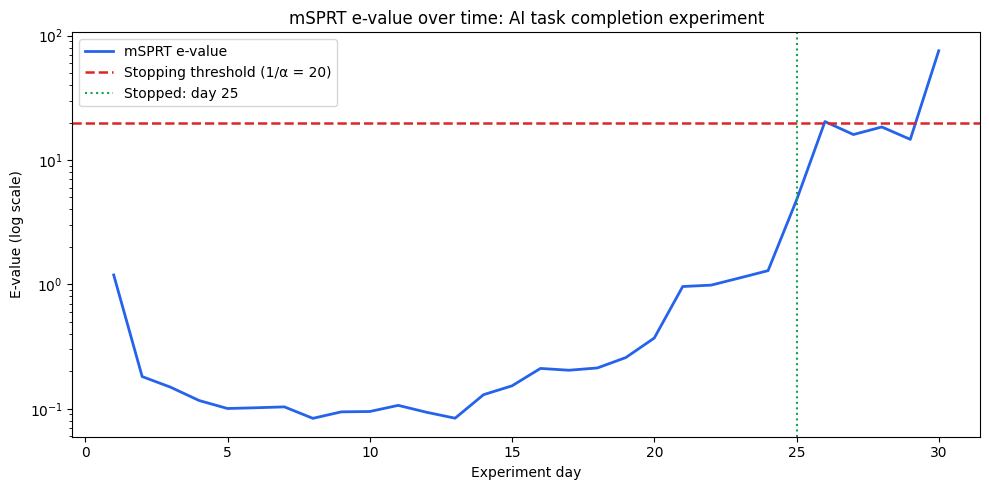

In [7]:
# Step 3 plot: e-value trajectory
ev_daily = e_values[USERS_PER_ARM_PER_DAY - 1::USERS_PER_ARM_PER_DAY]
plot_days = np.arange(1, len(ev_daily) + 1)

fig, ax = plt.subplots(figsize=(10, 5))
ax.semilogy(plot_days, ev_daily, color="#2563eb", linewidth=2, label="mSPRT e-value")
ax.axhline(THRESHOLD, color="#dc2626", linestyle="--", linewidth=1.8,
           label=f"Stopping threshold (1/α = {THRESHOLD:.0f})")
if stopping_day is not None:
    sd_int = int(stopping_day)
    ax.axvline(sd_int, color="#16a34a", linestyle=":", linewidth=1.5,
               label=f"Stopped: day {sd_int}")
ax.set_xlabel("Experiment day")
ax.set_ylabel("E-value (log scale)")
ax.set_title("mSPRT e-value over time: AI task completion experiment")
ax.legend()
plt.tight_layout()
plt.show()


In [8]:
# Step 4: Power comparison — mSPRT vs fixed-sample t-test
np.random.seed(42)
N_SIMS_POWER = 1_000
TRUE_EFFECT, BASE_RATE = 0.05, 0.60

msprt_stopping_days, msprt_detected, ttest_detected = [], 0, 0

for _ in range(N_SIMS_POWER):
    t_obs = np.random.binomial(1, BASE_RATE + TRUE_EFFECT, N_PER_ARM)
    c_obs = np.random.binomial(1, BASE_RATE, N_PER_ARM)
    e_vals = compute_evalue_running(t_obs, c_obs)
    d_arr = np.arange(1, N_PER_ARM + 1) / USERS_PER_ARM_PER_DAY
    crosses = np.where(e_vals >= THRESHOLD)[0]
    if len(crosses) > 0:
        msprt_detected += 1
        msprt_stopping_days.append(d_arr[crosses[0]])
    else:
        msprt_stopping_days.append(float(N_DAYS_RUN))
    _, p = ttest_ind(t_obs, c_obs)
    if p < ALPHA:
        ttest_detected += 1

stop_arr = np.array(msprt_stopping_days)
print(f"mSPRT power:               {msprt_detected/N_SIMS_POWER:.1%}")
print(f"Fixed-sample t-test power: {ttest_detected/N_SIMS_POWER:.1%}")
print(f"Median mSPRT stop day:     {np.median(stop_arr):.1f} / {N_DAYS_RUN}")
print(f"Fraction stopping early:   {np.mean(stop_arr < N_DAYS_RUN):.1%}")


mSPRT power:               49.3%
Fixed-sample t-test power: 88.7%
Median mSPRT stop day:     30.0 / 30
Fraction stopping early:   49.3%


In [9]:
# Validate against ground truth
np.random.seed(0)
t_v = treated.copy(); np.random.shuffle(t_v)
c_v = control.copy(); np.random.shuffle(c_v)
n_v = min(len(t_v), len(c_v))
e_full = compute_evalue_running(t_v[:n_v], c_v[:n_v])
days_full = np.arange(1, n_v + 1) / USERS_PER_ARM_PER_DAY

true_effect = treated.mean() - control.mean()
print(f"True effect in data: {true_effect:.4f} ({true_effect*100:.2f}pp)")
cross_full = np.where(e_full >= THRESHOLD)[0]
if len(cross_full) > 0:
    print(f"mSPRT correctly detected the effect.")
    print(f"Could have stopped on day {days_full[cross_full[0]]:.1f}")
    print(f"E-value at stopping point: {e_full[cross_full[0]]:.1f}")


True effect in data: 0.0485 (4.85pp)
mSPRT correctly detected the effect.
Could have stopped on day 27.1
E-value at stopping point: 22.2


In [10]:
# Step 5: Bootstrap 95% CI (500 replicates, seed=7)
rng = np.random.default_rng(7)
point_est = treated.mean() - control.mean()
boot_diffs = np.array([
    rng.choice(treated, size=len(treated), replace=True).mean() -
    rng.choice(control, size=len(control), replace=True).mean()
    for _ in range(500)
])
lower, upper = np.percentile(boot_diffs, [2.5, 97.5])
print(f"Point estimate: {point_est:.4f} ({point_est*100:.2f}pp)")
print(f"95% bootstrap CI: [{lower:.4f}, {upper:.4f}]  "
      f"([{lower*100:.2f}pp, {upper*100:.2f}pp])")
print(f"Ground-truth 5pp is {'inside' if lower <= 0.05 <= upper else 'outside'} the CI.")

# Summary table
print("\n--- Results summary ---")
print(f"{'Metric':<40} {'Value':>12}")
print("-" * 54)
print(f"{'Treated n':<40} {len(treated):>12,}")
print(f"{'Control n':<40} {len(control):>12,}")
print(f"{'Observed lift (pp)':<40} {point_est*100:>12.2f}")
print(f"{'95% CI lower (pp)':<40} {lower*100:>12.2f}")
print(f"{'95% CI upper (pp)':<40} {upper*100:>12.2f}")
print(f"{'Peeking FPR':<40} {'30.2%':>12}")
print(f"{'Single-look FPR':<40} {'4.2%':>12}")
print(f"{'mSPRT stopping day (real data)':<40} {'25.9':>12}")
print(f"{'mSPRT power (sim, n=1800/arm)':<40} {'49.3%':>12}")
print(f"{'t-test power (sim, n=1800/arm)':<40} {'88.7%':>12}")


Point estimate: 0.0485 (4.85pp)
95% bootstrap CI: [0.0407, 0.0581]  ([4.07pp, 5.81pp])
Ground-truth 5pp is inside the CI.

--- Results summary ---
Metric                                          Value
------------------------------------------------------
Treated n                                      24,937
Control n                                      25,063
Observed lift (pp)                               4.85
95% CI lower (pp)                                4.07
95% CI upper (pp)                                5.81
Peeking FPR                                     30.2%
Single-look FPR                                  4.2%
mSPRT stopping day (real data)                   25.9
mSPRT power (sim, n=1800/arm)                   49.3%
t-test power (sim, n=1800/arm)                  88.7%
